# Example NAS search

In [1]:
import reconstructions
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision

## Setup of the training data & default network

In [2]:
# some constants
bs = 64  # batch size
depth = 50  # number of hidden layers
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")  # check for devices
print(f"Device: {device} with {torch.cuda.device_count()} gpus")

# load training/test data
trans = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])
train_data = torchvision.datasets.CIFAR10("./", train=True, download=True, transform=trans)
val_data = torchvision.datasets.CIFAR10("./", train=False, transform=trans, download=True)
train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=bs, shuffle=True)
val_data_loader = torch.utils.data.DataLoader(val_data, batch_size=bs, shuffle=False)

Device: cpu with 0 gpus


In [3]:
# We create a VGG16 inspired CNN
dnetwork = nn.Sequential(*[
    # Block 1
    nn.Conv2d(3, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    # Block 2
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(128, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    # Block 3
    nn.Conv2d(128, 256, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    # Fully connected layers
    nn.Flatten(),
    nn.Linear(4096, 1000),
    nn.ReLU(),
    nn.Linear(1000, 10),
])

## Start NAS

Cascade done in 1.4612741470336914s


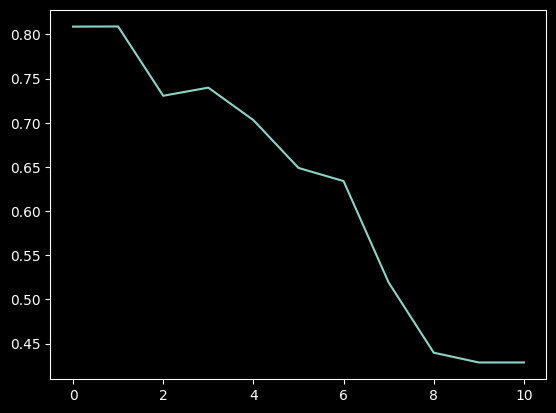

In [4]:
from reconstructions.nas import NasSuit, evaluate_score, guess_layer_improvement  # FIXME: remove and add to __init__.py in reconstructions
network = NasSuit(dnetwork, train_data_loader, val_data_loader, device=device)
plt.plot(network.get_entropy()[:-2])
plt.show()

We find a sudden loss of information in the 6th layer. This starts exactly subsequent to the Maxpooling at the end of the 2nd block. Therefore, we replace the Avgpooling layer.

In [5]:
#network[5] = nn.Conv2d(128, 128, kernel_size=2, stride=2, bias=False)
#plt.plot(network.get_entropy()[:-2])
#plt.show()

In [6]:
while True:
    # get entropies
    entropies, cascades = network.get_entropy(return_cascasdes=True)

    # evaluate which layer to change
    scores = evaluate_score(entropies, network.conet)
    index = np.argmax(scores)

    # predict which layer should fit better
    replacement = guess_layer_improvement(index, entropies, cascades, network.conet)



Cascade done in 1.5728096961975098s
[1.         0.99969093 0.99309755 0.9901608  0.97698546 0.95063476
 0.93891064 0.88623211 0.78087503 0.73402427 0.73402427 0.00196402]


array([ 0.00015932, -0.07842853,  0.00924493, -0.03691119, -0.05477183,
       -0.01527632, -0.1184691 , -0.08435133, -0.01252993,  0.        ,
       -0.0471926 ])